# Praktikum Data Visualization
### 4233201 – Kecerdasan Buatan | Semester Genap TA 2026/2027
### Week/Sesi: 2/3 | Nama: Tika Altiora Sitanggang | NIM: 42324025
## 0. Import Library dan Load Dataset
Dataset yang digunakan adalah dataset **iris** bawaan seaborn, untuk
mendemonstrasikan berbagai teknik visualisasi data.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier

# Load dataset
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 1. Histogram → Distribusi
Histogram digunakan untuk melihat sebaran (distribusi) satu variabel numerik,
di sini distribusi panjang kelopak (`petal_length`).

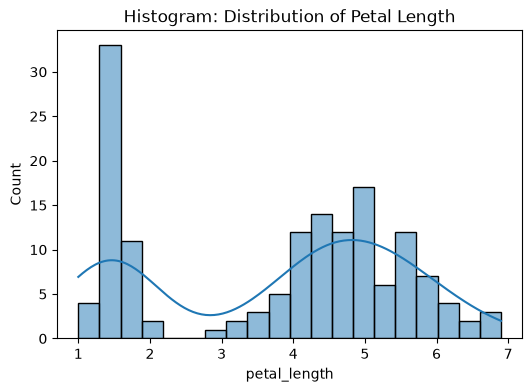

In [3]:
plt.figure(figsize=(6,4))
sns.histplot(df['petal_length'], bins=20, kde=True)
plt.title("Histogram: Distribution of Petal Length")
plt.show()

## 2. Bar Chart → Count per Category
Bar chart digunakan untuk melihat jumlah data pada tiap kategori, di sini
jumlah data untuk setiap spesies bunga.

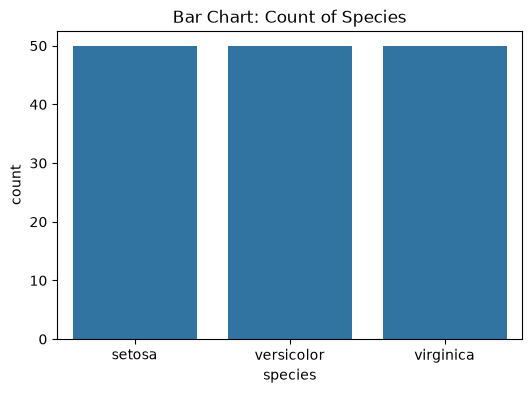

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(x="species", data=df)
plt.title("Bar Chart: Count of Species")
plt.show()

## 3. Box Plot → Spread + Outlier Detection
Box plot digunakan untuk melihat sebaran nilai (kuartil, median) sekaligus
mendeteksi outlier pada setiap kategori.

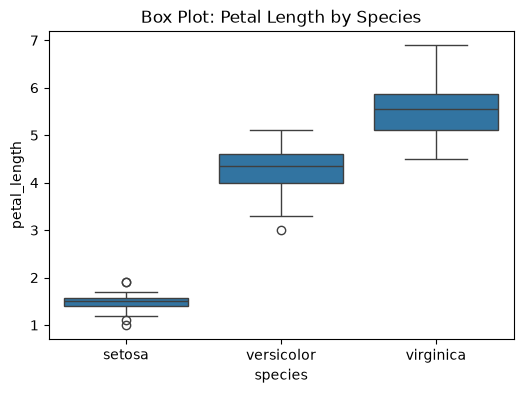

In [5]:
plt.figure(figsize=(6,4))
sns.boxplot(x="species", y="petal_length", data=df)
plt.title("Box Plot: Petal Length by Species")
plt.show()

## 4. Scatter Plot → Relationship
Scatter plot digunakan untuk melihat hubungan antara dua variabel numerik,
di sini `sepal_length` terhadap `petal_length`, dibedakan berdasarkan spesies.

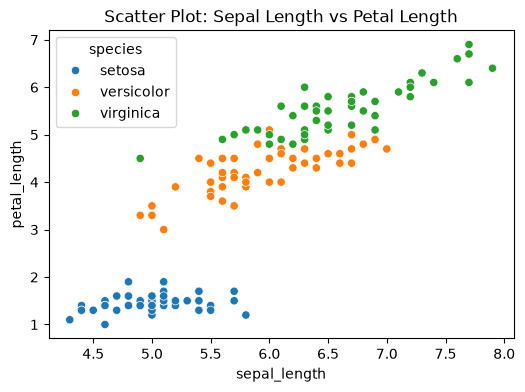

In [6]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="sepal_length", y="petal_length", hue="species", data=df)
plt.title("Scatter Plot: Sepal Length vs Petal Length")
plt.show()

## 5. Pair Plot → Multivariate Relationship
Pair plot digunakan untuk melihat hubungan antar semua pasangan variabel
numerik sekaligus dalam satu visualisasi.

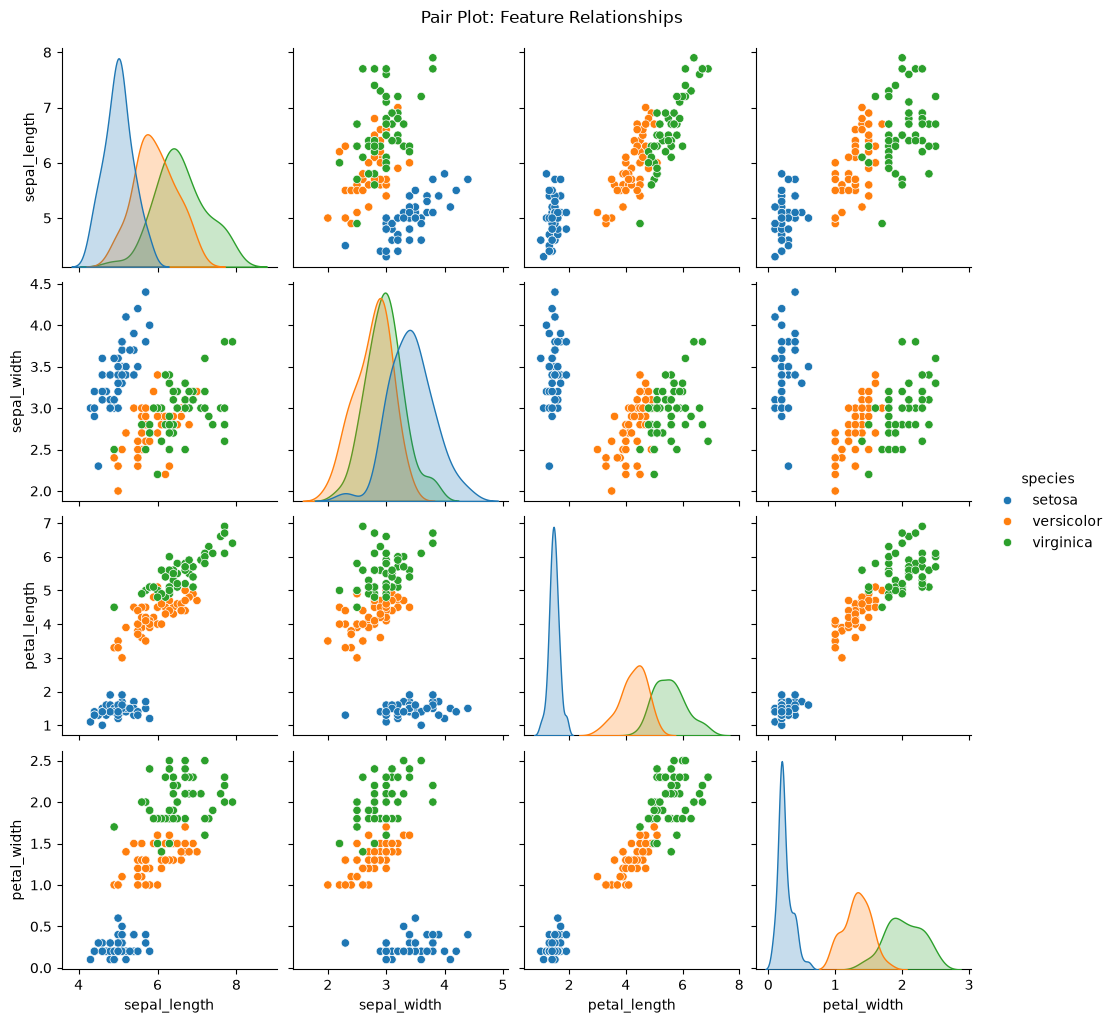

In [7]:
sns.pairplot(df, hue="species")
plt.suptitle("Pair Plot: Feature Relationships", y=1.02)
plt.show()

## 6. Line Plot → Example Time Series (Simulasi Cumulative Sum)
Line plot digunakan untuk melihat tren data sepanjang indeks/waktu. Di sini
dibuat data simulasi `random_growth` menggunakan cumulative sum dari angka acak.

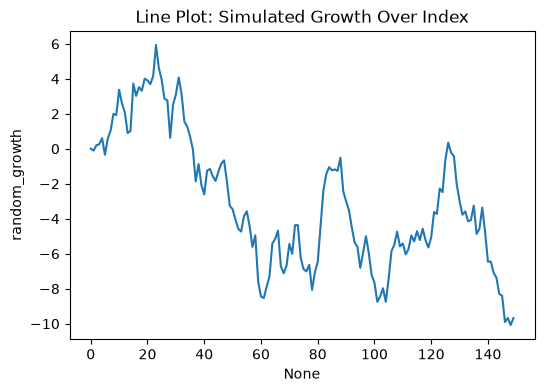

In [8]:
plt.figure(figsize=(6,4))
df["random_growth"] = np.random.randn(len(df)).cumsum()
sns.lineplot(x=df.index, y="random_growth", data=df)
plt.title("Line Plot: Simulated Growth Over Index")
plt.show()

## 7. Heatmap → Correlation Matrix
Heatmap digunakan untuk melihat kekuatan korelasi antar variabel numerik
secara sekaligus, dengan warna merah menandakan korelasi positif kuat dan
biru menandakan korelasi negatif kuat.

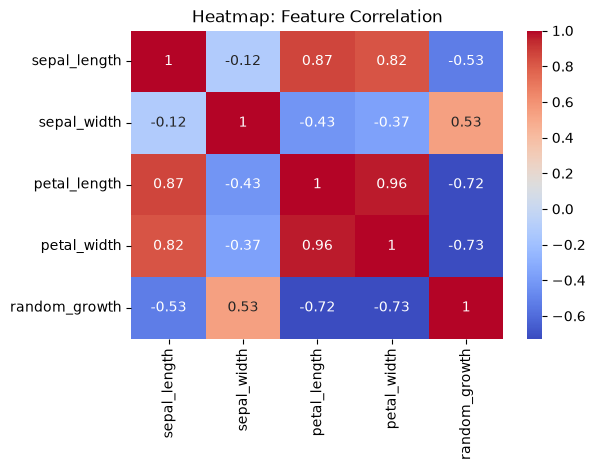

In [9]:
plt.figure(figsize=(6,4))
sns.heatmap(df.select_dtypes(include="number").corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap: Feature Correlation")
plt.show()

## 8. 3D Scatter Plot → 3 Features Visualization
3D scatter plot digunakan untuk memvisualisasikan hubungan tiga variabel
numerik sekaligus dalam satu ruang tiga dimensi.

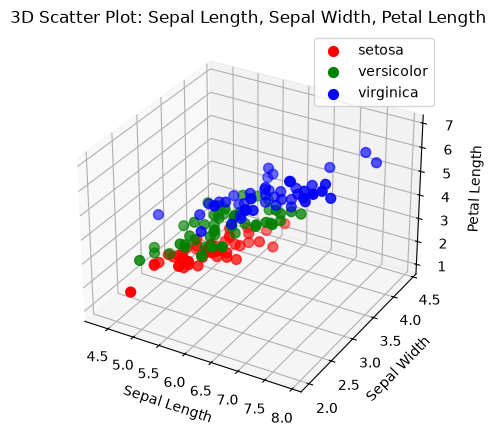

In [10]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection="3d")

species = df["species"].unique()
colors = ["r", "g", "b"]

for sp, col in zip(species, colors):
    subset = df[df["species"] == sp]
    ax.scatter(subset["sepal_length"], subset["sepal_width"], subset["petal_length"],
               c=col, label=sp, s=50)

ax.set_xlabel("Sepal Length")
ax.set_ylabel("Sepal Width")
ax.set_zlabel("Petal Length")
ax.set_title("3D Scatter Plot: Sepal Length, Sepal Width, Petal Length")
ax.legend()
plt.show()

## 9. Model-Specific Visualization (Random Forest)
### 9.1 Confusion Matrix
Melatih model RandomForestClassifier untuk mengklasifikasikan spesies, lalu
memvisualisasikan hasil prediksi terhadap label aktual menggunakan confusion matrix.

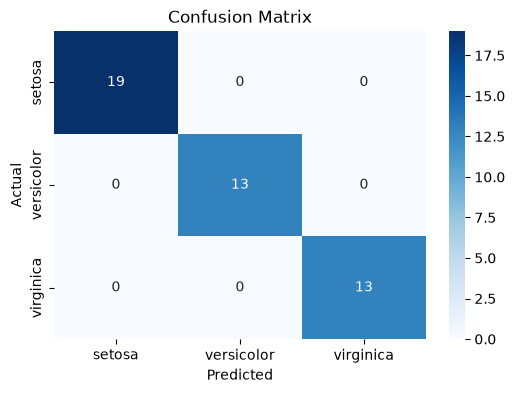

In [25]:
# Split data
X = df.drop("species", axis=1)
y = df["species"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 9.2 ROC–AUC Curve (Multi-class dengan One-vs-Rest)
Mengukur performa model pada tiap kelas menggunakan kurva ROC dan nilai AUC
dengan pendekatan One-vs-Rest, karena target bersifat multi-kelas.

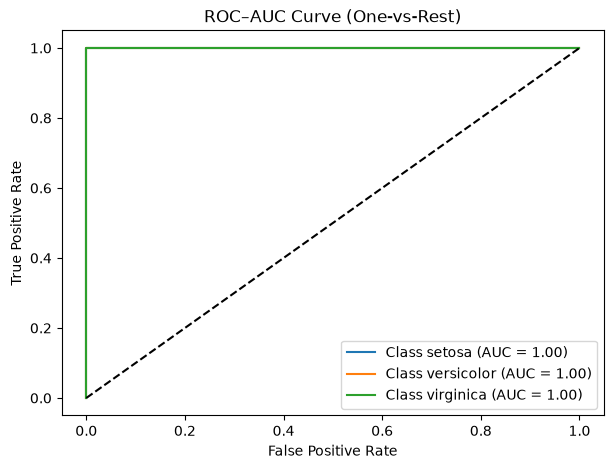

In [12]:
# Binarize labels
y_bin = label_binarize(y, classes=model.classes_)
n_classes = y_bin.shape[1]

# Train OvR classifier
ovr_model = OneVsRestClassifier(RandomForestClassifier(n_estimators=100, random_state=42))
ovr_model.fit(X_train, label_binarize(y_train, classes=model.classes_))

y_score = ovr_model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=model.classes_)

# Plot ROC curve
plt.figure(figsize=(7,5))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {model.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], "k--")  # diagonal
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC–AUC Curve (One-vs-Rest)")
plt.legend()
plt.show()

### 9.3 Feature Importance Plot → Random Forest
Menampilkan seberapa besar kontribusi tiap fitur terhadap keputusan model
Random Forest dalam mengklasifikasikan spesies.

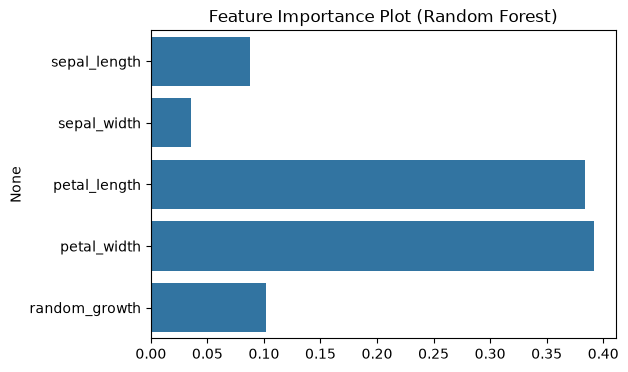

In [13]:
X = df.drop("species", axis=1)
y = df["species"]
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(6,4))
sns.barplot(x=importances, y=features)
plt.title("Feature Importance Plot (Random Forest)")
plt.show()

## Kesimpulan
Praktikum ini mendemonstrasikan berbagai teknik visualisasi data pada dataset
iris, mulai dari visualisasi distribusi satu variabel (histogram, bar chart),
hubungan antar variabel (scatter plot, pair plot, heatmap, 3D scatter plot),
tren berurut (line plot), hingga visualisasi khusus untuk evaluasi model
(confusion matrix, ROC–AUC curve, feature importance plot) menggunakan model
Random Forest.